# 01 — Análise Exploratória de Dados

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura não comunica nada.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
RAW = Path("..") / "data" / "raw"
APPLICATION_FILE = RAW / "application_record.csv"
CREDIT_FILE = RAW / "credit_record.csv"
PROCESSED = Path("..") / "data" / "processed"
TARGET = "TARGET"

pd.set_option("display.max_columns", None)

In [3]:
app_df = pd.read_csv(APPLICATION_FILE)
credit_df = pd.read_csv(CREDIT_FILE)

print(f"Aplicações: {app_df.shape}")
print(f"Histórico de crédito: {credit_df.shape}")
app_df.head()

Aplicações: (438557, 18)
Histórico de crédito: (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [4]:
print("Base de aplicações")
app_df.info()
display(app_df.describe(include="all").T)

print("Base de histórico de crédito")
credit_df.info()
display(credit_df.describe(include="all").T)

print("Nulos em aplicações:")
display(app_df.isna().sum().sort_values(ascending=False).head(10))
print("Duplicatas completas:", app_df.duplicated().sum())
print("IDs de aplicação duplicados:", app_df["ID"].duplicated().sum())

Base de aplicações
<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAI

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Base de histórico de crédito
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1048575.0,NaN,NaN,NaN,5068286.424673,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,NaN,NaN,NaN,-19.136998,14.023498,-60.0,-29.0,-17.0,-7.0,0.0
STATUS,1048575,8,C,442031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nulos em aplicações:


OCCUPATION_TYPE        134203
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
AMT_INCOME_TOTAL            0
dtype: int64

Duplicatas completas: 0
IDs de aplicação duplicados: 47


## 2. Distribuição das variáveis

As distribuições abaixo ajudam a identificar assimetrias e categorias dominantes. A idade é convertida para anos apenas nesta visualização; o tratamento definitivo fica no notebook 02.


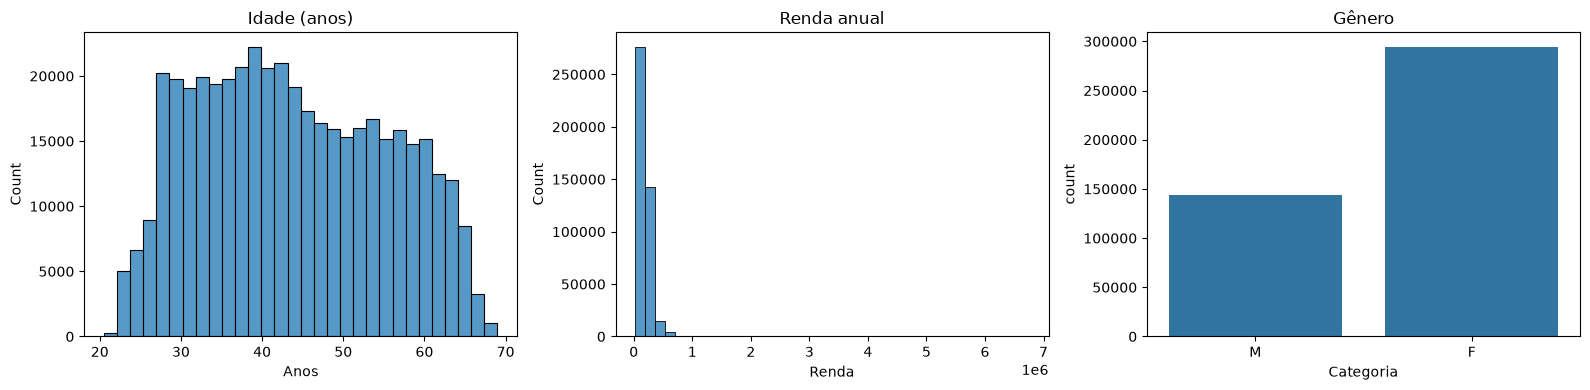

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(np.abs(app_df["DAYS_BIRTH"]) / 365.25, bins=30, ax=axes[0])
axes[0].set(title="Idade (anos)", xlabel="Anos")
sns.histplot(app_df["AMT_INCOME_TOTAL"], bins=40, ax=axes[1])
axes[1].set(title="Renda anual", xlabel="Renda")
sns.countplot(data=app_df, x="CODE_GENDER", ax=axes[2])
axes[2].set(title="Gênero", xlabel="Categoria")
plt.tight_layout()
plt.show()

**Interpretação:** idade e renda têm escalas e distribuições diferentes; renda costuma apresentar cauda longa, então a mediana e os quantis são mais informativos que a média isolada. A frequência por gênero descreve a composição da amostra, não uma relação causal com inadimplência.

## 3. Correlações

A correlação é calculada apenas entre variáveis numéricas da base de aplicações. Ela indica associação linear, não causalidade.


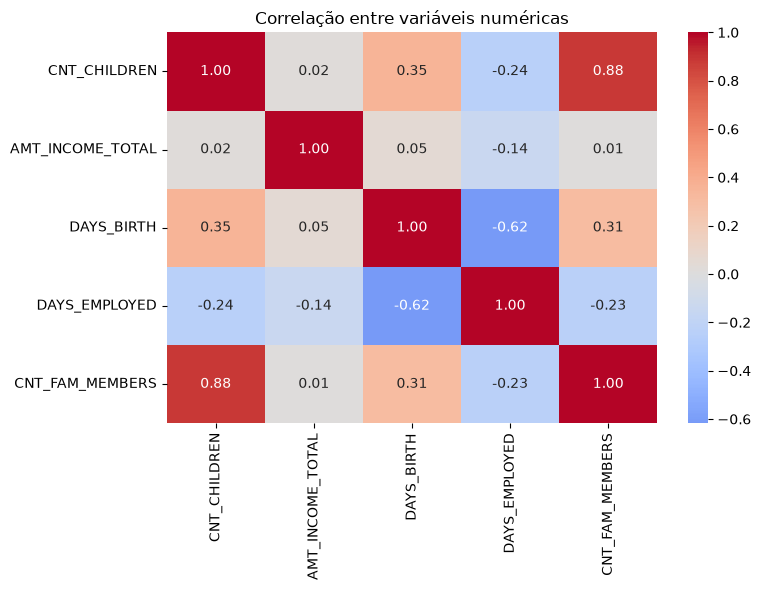

In [6]:
colunas_corr = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_FAM_MEMBERS"]
matriz_corr = app_df[colunas_corr].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

**Interpretação:** filhos e tamanho da família têm correlação de 0,88 e carregam informação semelhante; essa redundância pode ser considerada na modelagem. A correlação entre idade e tempo de emprego é de -0,62, mas os valores originais estão em dias negativos e o tempo de emprego ainda contém o sentinela que será tratado no notebook 02.

## 4. Outliers


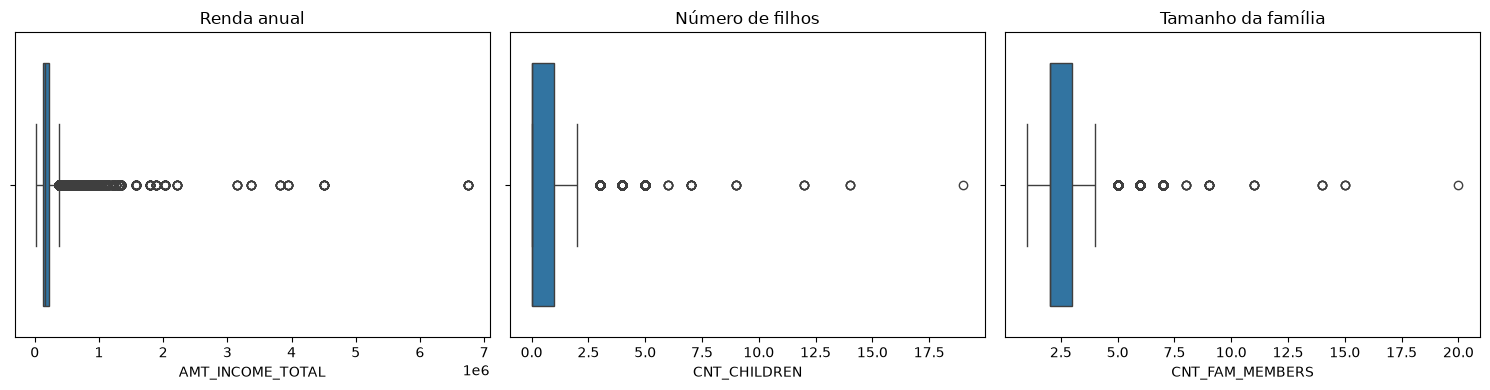

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=app_df["AMT_INCOME_TOTAL"], ax=axes[0])
axes[0].set_title("Renda anual")
sns.boxplot(x=app_df["CNT_CHILDREN"], ax=axes[1])
axes[1].set_title("Número de filhos")
sns.boxplot(x=app_df["CNT_FAM_MEMBERS"], ax=axes[2])
axes[2].set_title("Tamanho da família")
plt.tight_layout()
plt.show()

**Interpretação:** a renda apresenta valores extremos, enquanto filhos e membros da família têm faixas discretas. O notebook 02 limita apenas as caudas raras de tamanho familiar, sem excluir clientes por causa da renda.

## 5. Balanceamento de classes

A regra de inadimplência usada no projeto considera mau pagador quem teve status 2 a 5 em ao menos um mês do histórico. A unidade da contagem abaixo é o cliente.


,clientes
TARGET,
0,45318
1,667


,proporcao
MAU_PAGADOR,
0,0.985495
1,0.014505


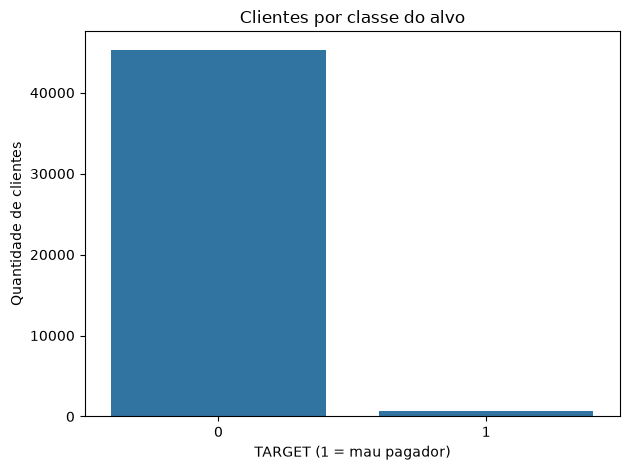

In [8]:
credit_df["MAU_PAGADOR"] = credit_df["STATUS"].isin(["2", "3", "4", "5"])
target_eda = credit_df.groupby("ID")["MAU_PAGADOR"].max().astype(int)
display(target_eda.value_counts().rename_axis(TARGET).to_frame("clientes"))
display(target_eda.value_counts(normalize=True).rename("proporcao").to_frame())

sns.countplot(x=target_eda)
plt.title("Clientes por classe do alvo")
plt.xlabel("TARGET (1 = mau pagador)")
plt.ylabel("Quantidade de clientes")
plt.tight_layout()
plt.show()

**Interpretação:** no histórico completo, 667 de 45.985 clientes (1,45%) são positivos pela regra de atraso de 60 dias ou mais. Essa forte assimetria torna a acurácia isolada inadequada; o notebook 03 também compara recall e F1 da classe positiva.

## 6. Síntese da EDA

A base de aplicações contém variáveis cadastrais, com ocupação apresentando muitos valores ausentes e renda com cauda longa. `DAYS_BIRTH` e `DAYS_EMPLOYED` estão em dias negativos; o valor 365243 em tempo de emprego é um sentinela que deve ser tratado. Há IDs de aplicação duplicados que precisam de uma regra explícita. O histórico de crédito permite definir o alvo por cliente, mas a classe positiva é rara e exige métricas adequadas ao desbalanceamento.
